# 10 · Illustrative premium and reserve underwriting-risk SCR component

Standard Formula premium and reserve risk for a made-up EUR case, as of 2026-09-30. It is one component of the non-life underwriting SCR. It is not a total SCR and it does not use freMTPL2 or CAS. Every financial input is an assumption. Segments are Annex II 1 and 5, geographic factor 1.

In [1]:
import sys
from pathlib import Path
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / 'src' / 'project.py').is_file():
        project_root = parent
        break
else:
    raise RuntimeError('Run from the project root or from notebooks/.')
sys.path.insert(0, str(project_root / 'src'))
from project import DATA_DIR, RESULTS_DIR, result_path, setup, require_results, record_results
setup()
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import asdict, replace
from solvency_model import SegmentInputs, premium_reserve_scr, PARAMETERS, RESULT_NAME

## Regulatory basis

Use Regulation (EU) 2015/35, consolidated version listed as 2024-11-14, with Articles 115–117 and Annexes II/IV applicable on 2026-09-30. Sources checked on that date:

- [Article 115](https://www.eiopa.europa.eu/rulebook/solvency-ii/article-2552_en): component = 3 σ V.
- [Article 116](https://www.eiopa.europa.eu/rulebook/solvency-ii-single-rulebook/article-2553_en): premium/reserve volumes and geographic factor.
- [Article 117](https://www.eiopa.europa.eu/rulebook/solvency-ii-single-rulebook/article-2554_en): aggregation and default reinsurance adjustment.
- [2019/981, Annex I replacing Annex II](https://eur-lex.europa.eu/legal-content/EN/ALL/?uri=CELEX:32019R0981): risk coefficients.
- [2015/35, Article 117 and Annex IV, printed pages 74 and 233](https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?from=EN&qid=1460029062072&uri=CELEX:32015R0035): square root in segment sigma and correlation matrix. The EIOPA HTML transcription omits the square-root symbol; the official formula includes it.
- [2026/269, Article 2](https://eur-lex.europa.eu/eli/reg_del/2026/269/oj/eng/pdf): changes apply from 2027-01-30 and are not applied here.

The consolidated EUR-Lex body was blocked by its access check. The implemented provisions were checked against the EIOPA articles and official amending/original texts above; this is not a review of every regulatory provision.

## Segments and data boundary

| Case segment | Annex II | Annex I lines | Gross premium sigma | Reserve sigma | Premium adjustment |
|---|---:|---|---:|---:|---:|
| Motor vehicle liability | 1 | 4, 16 | 10% | 9% | 80% |
| General liability | 5 | 8, 20 | 14% | 11% | 80% |

Correlation between these segments is 0.5. The 80% factor is the Article 117(3) default in this version, not a fitted treaty benefit.

freMTPL2 motor liability has a conceptual segment-1 mapping, but lacks the required forward premiums and regulatory claims best estimate. CAS labels and accounting reserves do not establish EU contract classification or discounted regulatory volumes. Workers’ compensation cannot be assigned to segment 1 or 5 by its name. No CAS or motor result is imported into this case.

## Volume assumptions

Amounts in EUR million. Premiums are net of eligible reinsurance. Reserve inputs are assumed discounted best estimates and eligible recoverables, not Mack errors or accounting reserves. Short-contract future premiums exclude the first 12 months after recognition; long-contract future premiums go beyond the next valuation year and get the 30% factor. Eligibility under Articles 209–213 is assumed, not checked. DIV = 1 means no geographic credit.

In [2]:
inputs = [
    SegmentInputs(segment=1, next_12m_net_earned=100, last_12m_net_earned=110,
        future_existing_pv=8, future_new_short_pv=2, future_new_long_pv=10,
        gross_claims_best_estimate=90, eligible_recoverables=15),
    SegmentInputs(segment=5, next_12m_net_earned=60, last_12m_net_earned=55,
        future_existing_pv=5, future_new_short_pv=1, future_new_long_pv=20,
        gross_claims_best_estimate=130, eligible_recoverables=20),
]
display(pd.DataFrame([asdict(x) for x in inputs]).set_index('segment'))

,next_12m_net_earned,last_12m_net_earned,future_existing_pv,future_new_short_pv,future_new_long_pv,gross_claims_best_estimate,eligible_recoverables
segment,,,,,,,
1,100,110,8,2,10,90,15
5,60,55,5,1,20,130,20


## Calculation

$V_{prem} = \max(P_{next},P_{last}) + FP_{existing} + FP_{short} + 0.3 FP_{long}$.
$V_{res}=\max(BE_{claims}-recoverables,0)$ and $V_s=V_{prem}+V_{res}$ for DIV=1.
With $a=\sigma_{prem}V_{prem}$ and $b=\sigma_{res}V_{res}$, $w_s=\sqrt{a^2+ab+b^2}=\sigma_sV_s$.
The component is $3\sqrt{\sum_{s,t} Corr_{s,t}w_sw_t}$.

In [3]:
result = premium_reserve_scr(inputs)
display(pd.DataFrame(result['segments']).set_index('segment').round(3))
print(f"{RESULT_NAME}: EUR {result['scr']:,.3f} million")
w1 = np.sqrt((.08*123)**2 + (.08*123)*(.09*75) + (.09*75)**2)
w5 = np.sqrt((.112*72)**2 + (.112*72)*(.11*110) + (.11*110)**2)
np.testing.assert_allclose(result['scr'], 3*np.sqrt(w1*w1+w1*w5+w5*w5), rtol=1e-12)
assert [x['premium_volume'] for x in result['segments']] == [123, 72]
assert [x['reserve_volume'] for x in result['segments']] == [75, 110]

,premium_volume,reserve_volume,volume,premium_sigma,reserve_sigma,sigma,weighted_sigma,standalone_scr
segment,,,,,,,,
1,123.000,75,198.000,0.080,0.090,0.073,14.450,43.351
5,72.000,110,182.000,0.112,0.110,0.097,17.579,52.736


Illustrative premium and reserve underwriting-risk SCR component (Standard Formula): EUR 83.346 million


## Sensitivity

Forward earned premium or claims best estimates up 20%, everything else fixed. These are volume scenarios, not a regulatory stress. Component goes from 83.346 to 88.127 (premium) and 93.827 (claims).

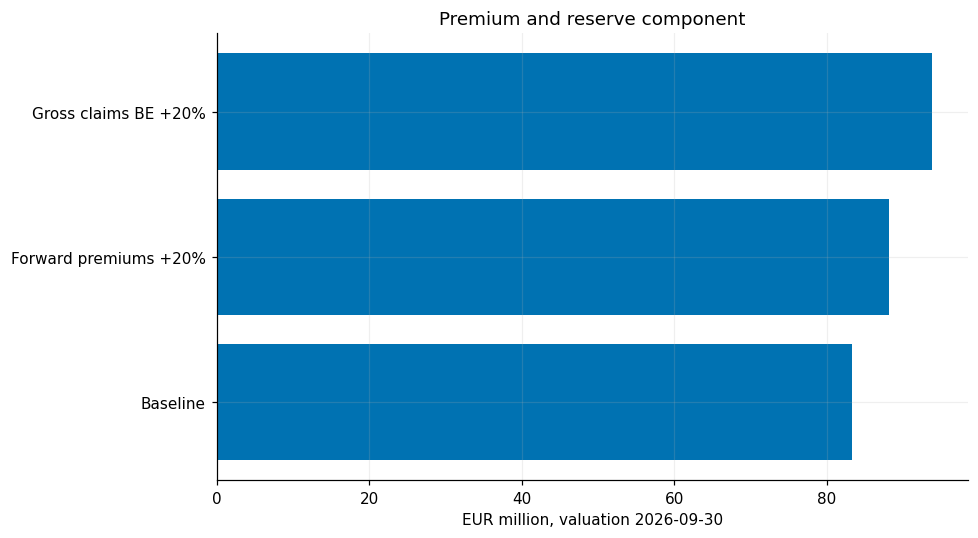

In [4]:
cases = {'Baseline': inputs,
    'Forward premiums +20%': [replace(x, next_12m_net_earned=x.next_12m_net_earned*1.2) for x in inputs],
    'Gross claims BE +20%': [replace(x, gross_claims_best_estimate=x.gross_claims_best_estimate*1.2) for x in inputs]}
charges = {name:premium_reserve_scr(rows)['scr'] for name,rows in cases.items()}
fig, ax = plt.subplots()
ax.barh(list(charges), list(charges.values()), color='C0')
ax.set_xlabel('EUR million, valuation 2026-09-30'); ax.set_title('Premium and reserve component')
plt.tight_layout(); plt.show()
result['input_status'] = 'All financial inputs assumed; separate illustrative regulatory case'
result['scope'] = 'illustrative premium and reserve underwriting-risk SCR component (Standard Formula, segments 1 and 5); not a total SCR'
result['currency'] = 'EUR million'
result['not_included'] = ['catastrophe risk', 'lapse risk', 'other non-life underwriting segments', 'module aggregation',
    'market risk', 'counterparty default risk', 'operational risk', 'loss-absorbing capacity of technical provisions and deferred taxes',
    'SCR adjustments and add-ons']
result['inputs'] = [asdict(x) for x in inputs]
result['sensitivities'] = charges
json.dump(result, open(result_path('scr_results.json'),'w'), indent=2)
record_results('scr_results.json')

- Volumes include the prior-premium floor and the future-premium terms.
- Coefficients and correlations follow the provisions cited above.
- The illustrative premium and reserve underwriting-risk SCR component is EUR 83.346 million; the two sensitivities are above.
- Not included: catastrophe risk, lapse risk, other non-life underwriting segments, non-life/life/health module aggregation, market risk, counterparty default risk, operational risk, the loss-absorbing capacity of technical provisions and deferred taxes, and any SCR adjustments or add-ons.
- The result is a standalone regulatory illustration. It is not compared with the empirical USD/EUR proxies in 11 on a like-for-like basis, because volumes, measure (one-year 99.5% Standard Formula vs simulated VaR/ES) and currency differ.